# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [1]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [2]:
# A.1 — spec table
specs = []

for name, model in models.items():
    config = model.config

    specs.append({
        "Model": name,
        "Layers": config.n_layer,
        "Width": config.n_embd,
        "Heads": config.n_head,
        "Context": config.n_ctx,
        "Parameters": sum(p.numel() for p in model.parameters())
    })

specs.append({
    "Model": "gpt2-medium",
    "Layers": 24,
    "Width": 1024,
    "Heads": 16,
    "Context": 1024,
    "Parameters": 355_000_000
})

spec_df = pd.DataFrame(specs)

spec_df

,Model,Layers,Width,Heads,Context,Parameters
0,distilgpt2,6,768,12,1024,81912576
1,gpt2,12,768,12,1024,124439808
2,gpt2-medium,24,1024,16,1024,355000000


In [9]:
def census(m):
    """Count parameters by component for a GPT-2-family model."""

    counts = {
        "embeddings (wte+wpe)": 0,
        "attention": 0,
        "ffn (mlp)": 0,
        "layernorms": 0,
        "lm_head (tied)": 0
    }

    for name, p in m.named_parameters():
        n = p.numel()

        if "wte" in name or "wpe" in name:
            counts["embeddings (wte+wpe)"] += n

        elif ".attn." in name:
            counts["attention"] += n

        elif ".mlp." in name:
            counts["ffn (mlp)"] += n

        elif "ln" in name:
            counts["layernorms"] += n

    total = sum(p.numel() for p in m.parameters())

    return counts, total


# Run census for both loaded models
for model_name, model in models.items():

    counts, total = census(model)

    print(f"\n{'=' * 55}")
    print(f"Model: {model_name}")
    print(f"{'=' * 55}")

    print(f"{'Component':<24} {'Params':>14} {'Share':>8}")

    for k, v in counts.items():
        print(f"{k:<24} {v:>14,} {v/total:>7.1%}")

    print("-" * 48)
    print(f"{'TOTAL':<24} {total:>14,}")

    print(
        f"\nFFN / attention ratio: "
        f"{counts['ffn (mlp)'] / counts['attention']:.2f}×"
    )


Model: distilgpt2
Component                        Params    Share
embeddings (wte+wpe)         39,383,808   48.1%
attention                    14,174,208   17.3%
ffn (mlp)                    28,334,592   34.6%
layernorms                       19,968    0.0%
lm_head (tied)                        0    0.0%
------------------------------------------------
TOTAL                        81,912,576

FFN / attention ratio: 2.00×

Model: gpt2
Component                        Params    Share
embeddings (wte+wpe)         39,383,808   31.6%
attention                    28,348,416   22.8%
ffn (mlp)                    56,669,184   45.5%
layernorms                       38,400    0.0%
lm_head (tied)                        0    0.0%
------------------------------------------------
TOTAL                       124,439,808

FFN / attention ratio: 2.00×


**A.3 — Interpretation (3–4 sentences):**

DistilGPT-2 and GPT-2 have the same embedding size, so their embedding parameters stay constant. GPT-2 has twice as many layers, so the repeated attention and FFN parameters approximately double. The FFN is the largest component, with twice as many parameters as attention in both models. Therefore, much of the model-size increase comes from stacking more Transformer layers, especially the FFN blocks.

---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [10]:
# B.1 — predictor + validation
def predict_params(layers, width, vocab=50257, ctx=1024):
    # Embeddings
    embedding_params = vocab * width + ctx * width

    # Attention per transformer block
    attention_per_layer = 4 * width**2 + 4 * width

    # FFN per transformer block
    ffn_per_layer = 8 * width**2 + 5 * width

    # LayerNorms per transformer block
    layernorm_per_layer = 4 * width

    # Total parameters
    total = (
        embedding_params
        + layers * (
            attention_per_layer
            + ffn_per_layer
            + layernorm_per_layer
        )
    )

    return total
actual_distil = 81_912_576
actual_gpt2 = 124_439_808

pred_distil = predict_params(6, 768)
pred_gpt2 = predict_params(12, 768)

error_distil = abs(pred_distil - actual_distil) / actual_distil * 100
error_gpt2 = abs(pred_gpt2 - actual_gpt2) / actual_gpt2 * 100

print("DistilGPT-2")
print(f"Predicted: {pred_distil:,}")
print(f"Actual:    {actual_distil:,}")
print(f"Error:     {error_distil:.2f}%")

print("\nGPT-2")
print(f"Predicted: {pred_gpt2:,}")
print(f"Actual:    {actual_gpt2:,}")
print(f"Error:     {error_gpt2:.2f}%")


DistilGPT-2
Predicted: 81,911,040
Actual:    81,912,576
Error:     0.00%

GPT-2
Predicted: 124,438,272
Actual:    124,439,808
Error:     0.00%


In [11]:
# B.2 — extrapolate gpt2-medium
pred_medium = predict_params(24, 1024)

print(f"Predicted GPT-2-medium parameters: {pred_medium:,}")


Predicted GPT-2-medium parameters: 354,821,120


In [12]:
# B.3 — memory table (fp32 / fp16, in MB) for all three

models_params = {
    "distilgpt2": 81_912_576,
    "gpt2": 124_439_808,
    "gpt2-medium": pred_medium
}

memory_rows = []

for model_name, params in models_params.items():
    fp32_mb = params * 4 / (1024 ** 2)
    fp16_mb = params * 2 / (1024 ** 2)

    memory_rows.append({
        "Model": model_name,
        "Parameters": params,
        "FP32 (MB)": fp32_mb,
        "FP16 (MB)": fp16_mb
    })

memory_df = pd.DataFrame(memory_rows)

memory_df

,Model,Parameters,FP32 (MB),FP16 (MB)
0,distilgpt2,81912576,312.471680,156.235840
1,gpt2,124439808,474.700195,237.350098
2,gpt2-medium,354821120,1353.535156,676.767578


---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

In [15]:
# C.1 — benchmark (adapt time_generation() from the lab)
import time
import pandas as pd
import matplotlib.pyplot as plt


def time_generation(
    m,
    n_new_tokens,
    use_cache,
    prompt="The history of artificial intelligence",
    runs=3
):
    ids = tok.encode(prompt, return_tensors="pt")
    times = []

    for _ in range(runs):
        t0 = time.perf_counter()

        with torch.no_grad():
            m.generate(
                ids,
                max_new_tokens=n_new_tokens,
                do_sample=False,
                use_cache=use_cache,
                pad_token_id=tok.eos_token_id
            )

        times.append(time.perf_counter() - t0)

    return min(times)


lengths = [10, 25, 50]

results = []

for model_name, model in models.items():

    print(f"\n{model_name}")

    for n in lengths:

        tc = time_generation(model, n, use_cache=True)
        tn = time_generation(model, n, use_cache=False)

        results.append({
            "Model": model_name,
            "Tokens": n,
            "Cache": "ON",
            "Latency (s)": tc
        })

        results.append({
            "Model": model_name,
            "Tokens": n,
            "Cache": "OFF",
            "Latency (s)": tn
        })

        print(
            f"{n:>3} tokens: "
            f"cache ON {tc:.3f}s   "
            f"cache OFF {tn:.3f}s   "
            f"speedup {tn/tc:.2f}×"
        )


results_df = pd.DataFrame(results)

results_df



distilgpt2
 10 tokens: cache ON 0.509s   cache OFF 1.104s   speedup 2.17×
 25 tokens: cache ON 0.947s   cache OFF 2.018s   speedup 2.13×
 50 tokens: cache ON 1.768s   cache OFF 4.603s   speedup 2.60×

gpt2
 10 tokens: cache ON 0.586s   cache OFF 1.325s   speedup 2.26×
 25 tokens: cache ON 1.381s   cache OFF 3.703s   speedup 2.68×
 50 tokens: cache ON 2.773s   cache OFF 8.993s   speedup 3.24×


,Model,Tokens,Cache,Latency (s)
0,distilgpt2,10,ON,0.508932
1,distilgpt2,10,OFF,1.104411
2,distilgpt2,25,ON,0.946900
3,distilgpt2,25,OFF,2.018229
4,distilgpt2,50,ON,1.768183
5,distilgpt2,50,OFF,4.602931
6,gpt2,10,ON,0.586388
7,gpt2,10,OFF,1.324568
8,gpt2,25,ON,1.380997
9,gpt2,25,OFF,3.703091


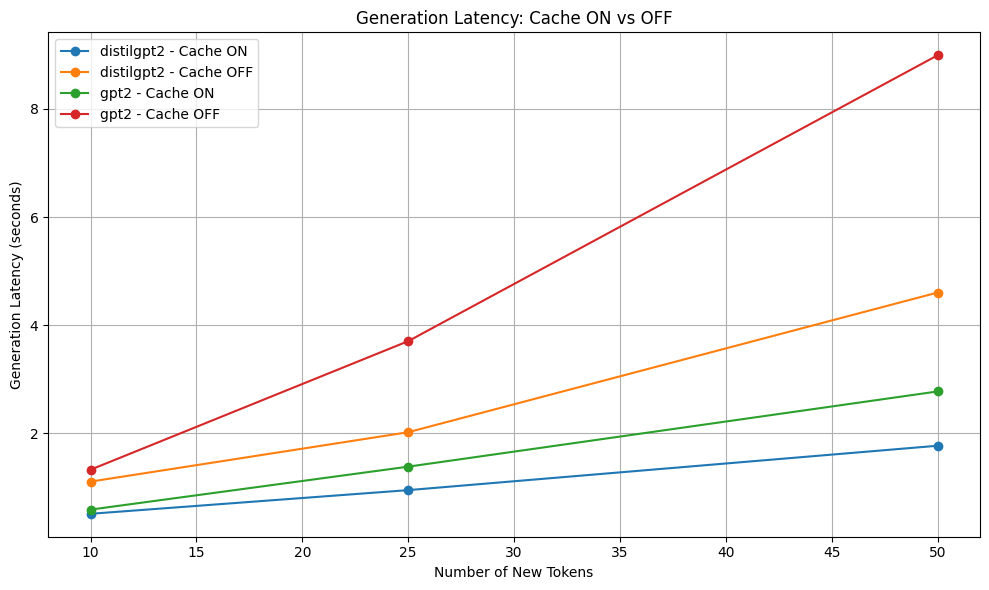

In [16]:
# C.1 — Plot benchmark results

plt.figure(figsize=(10, 6))

for model_name in results_df["Model"].unique():

    for cache_type in ["ON", "OFF"]:

        subset = results_df[
            (results_df["Model"] == model_name) &
            (results_df["Cache"] == cache_type)
        ]

        plt.plot(
            subset["Tokens"],
            subset["Latency (s)"],
            marker="o",
            label=f"{model_name} - Cache {cache_type}"
        )

plt.xlabel("Number of New Tokens")
plt.ylabel("Generation Latency (seconds)")
plt.title("Generation Latency: Cache ON vs OFF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# C.2 — the 300 ms test at your chosen autocomplete length

autocomplete_tokens = 10
target_ms = 300

c2_results = []

for model_name, model in models.items():

    latency_s = time_generation(
        model,
        autocomplete_tokens,
        use_cache=True
    )

    latency_ms = latency_s * 1000
    meets_requirement = latency_ms < target_ms

    c2_results.append({
        "Model": model_name,
        "Tokens": autocomplete_tokens,
        "Cache": "ON",
        "Latency (ms)": latency_ms,
        "Target (ms)": target_ms,
        "Meets <300ms": meets_requirement
    })

c2_df = pd.DataFrame(c2_results)

c2_df

,Model,Tokens,Cache,Latency (ms),Target (ms),Meets <300ms
0,distilgpt2,10,ON,640.492137,300,False
1,gpt2,10,ON,792.405414,300,False


**C.3 — Extrapolation & confidence (2–3 sentences):**

GPT-2-medium is unlikely to meet the 300 ms requirement on this hardware. GPT-2 already takes 792.4 ms for 10 new tokens with cache enabled, while GPT-2-medium has about 2.9× more parameters, 2× the layers, and 1.33× the width. Confidence: high, although the exact latency cannot be known without directly benchmarking GPT-2-medium.

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

# Model Selection Memo — Meridian Docs Autocomplete

**Recommendation:** Select **DistilGPT-2 with high confidence** as the better candidate for Meridian Docs Autocomplete, while recognizing that it does not currently meet the <300 ms latency target on the tested hardware.

**Why**

* **Latency:** At the chosen 10-token autocomplete length with KV cache enabled, DistilGPT-2 measured **640.5 ms**, compared with **792.4 ms** for GPT-2. DistilGPT-2 is therefore the faster tested model, although both exceed the 300 ms requirement.
* **Memory:** DistilGPT-2 has **81.9M parameters**, requiring about **312.5 MB in FP32** or **156.2 MB in FP16**, compared with GPT-2's **124.4M parameters** and **474.7 MB FP32 / 237.4 MB FP16**. This makes DistilGPT-2 the lighter deployment candidate.
* **Architecture/parameter evidence:** The parameter census shows DistilGPT-2 uses **28.33M parameters in its FFN** and **14.17M in attention**, while GPT-2 uses **56.67M FFN** and **28.35M attention**. The smaller model therefore provides lower compute and memory requirements while preserving the same GPT-2-family structure.

**The "biggest wins" rebuttal:** GPT-2-medium is not the safer choice for this latency-constrained product. It has about **2.9× the parameters of GPT-2**, twice the layers, and 1.33× the width, while GPT-2 already measured **792.4 ms** for 10 cached tokens—well above the 300 ms target. GPT-2-medium was not downloaded or benchmarked, so its exact latency is unknown, but the available evidence makes meeting 300 ms unlikely.

**Known limitation:** The most serious limitation is that this methodology evaluates **latency and resource usage, not autocomplete quality**; model quality, relevance, and user experience were not tested.


---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [ ] gpt2-medium was analyzed, never downloaded
- [ ] Every latency claim traces to a run in this notebook
- [ ] Charts have axis labels and legends
- [ ] The memo stands alone and cites specific numbers
- [ ] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*